## 2.2 Hopeld network recall

In [67]:
import numpy as np

# three memory

x1=np.array([-1,-1,1 ,-1 ,1 ,-1 ,-1 ,1])
x2=np.array([-1 ,-1, -1 ,-1 ,-1 ,1, -1, -1])
x3=np.array([-1, 1 ,1 ,-1 ,-1, 1 ,-1, 1])



# compute the weight matrix 
def weight_hop(X):
    p=len(X)
    n=len(X[0])
    W=np.zeros((n,n))
    for i in range(n):
        for j in range(n):
            if i!=j:
                for x in X:
                    W[i][j]+=x[i]*x[j]
    return W/p

def update_patt(W,x):

    new_x=np.sign(W@x).astype(int)
    return new_x


def check_memory(W,X):
    for i,x in enumerate(X):
        print(x)
        new_x=update_patt(W,x)
        print(new_x)
        if np.array_equal(new_x, x):
            print(f"Pattern {i+1} memorized")
        else:
            print(f"Updated: {new_x}")
            print(f"Pattern {i+1} NOT memorized")

X=(x1,x2,x3)

W=weight_hop(X)

check_memory(W,X)









[-1 -1  1 -1  1 -1 -1  1]
[-1 -1  1 -1  1 -1 -1  1]
Pattern 1 memorized
[-1 -1 -1 -1 -1  1 -1 -1]
[-1 -1 -1 -1 -1  1 -1 -1]
Pattern 2 memorized
[-1  1  1 -1 -1  1 -1  1]
[-1  1  1 -1 -1  1 -1  1]
Pattern 3 memorized


## 3.1 Convergence and attractors

In [68]:
import matplotlib.pyplot as plt 

# distance hamming

def plot_hamming(W, x_init, target_patterns, max_iter=100):
    current = x_init.copy()
    
    distances = {f'x{i+1}': [] for i in range(len(target_patterns))}
    history = [current.copy()]
    iter=0
    
    while (iter<max_iter):
        for i, target in enumerate(target_patterns):
            dist = np.sum(current != target)
            distances[f'x{i+1}'].append(dist)
            if dist==0:
                break
        
        new_x = update_patt(W, current)
        
        history.append(new_x.copy())
        current = new_x
        iter+=1
    
    # Plot
    plt.figure(figsize=(10, 5))
    for name, dists in distances.items():
        plt.plot(dists, marker='o', label=name)
    
    plt.xlabel('Iteration')
    plt.ylabel('Hamming Distance')
    plt.title('Distance evolution')
    plt.legend()
    plt.grid(True)
    plt.show()



Converegence of distorted patterns
Pattern:
[-1 -1  1 -1  1 -1 -1  1]
Nb of iterations:2


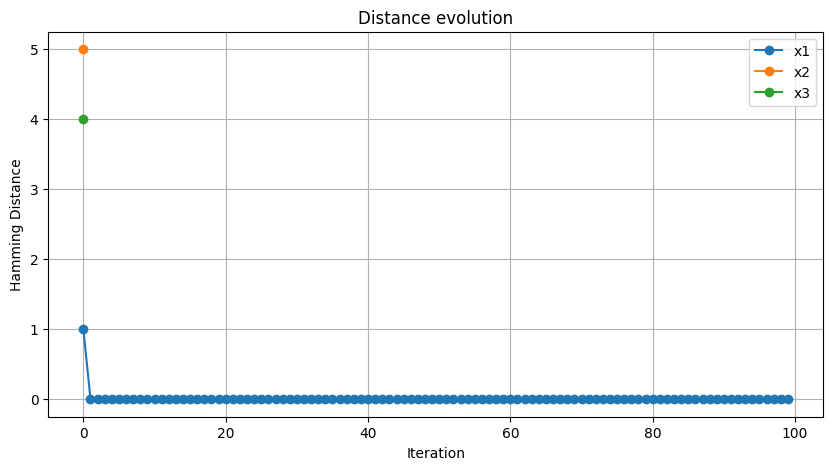

This is x1 (stored pattern)
Pattern:
Warning we have not converge yet
[ 1  1 -1 -1 -1  1 -1 -1]
Nb of iterations:1000


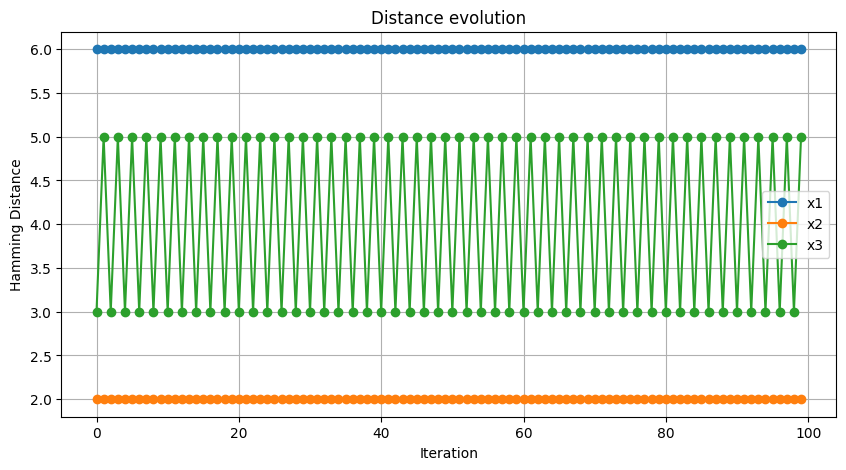

Spurious attractor (NOT stored)
Pattern:
Warning we have not converge yet
[-1 -1  1 -1  1  1 -1  1]
Nb of iterations:1000


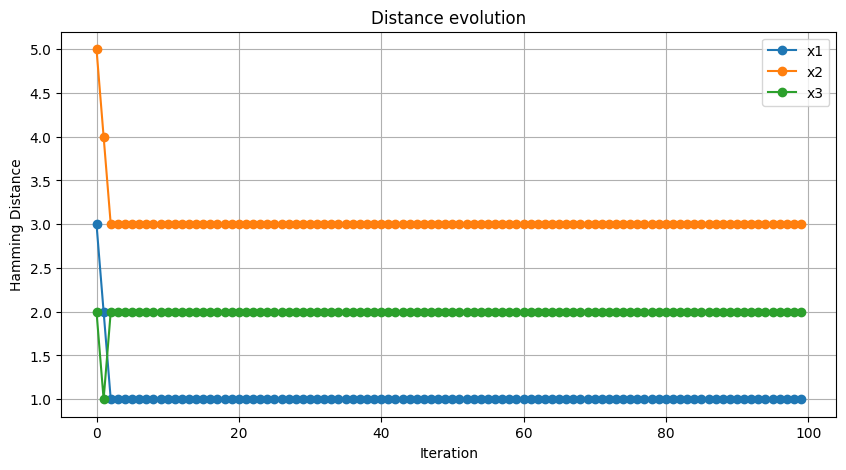

Spurious attractor (NOT stored)


In [69]:
# distorted patterns

x1d=np.array([ 1, -1 ,1 ,-1, 1, -1 ,-1 ,1])
x2d=np.array([ 1 ,1, -1 ,-1 ,-1 ,1 ,-1 ,-1])
x3d=np.array([ 1,1 ,1, -1 ,1 ,1 ,-1 ,1])

Xd=(x1d,x2d,x3d)

def sync_hop(W, x,max_iter=1000):
    current = x.copy()
    L=[]
    for iter in range(1, max_iter + 1):
        new_x = update_patt(W, current)
        
        if np.array_equal(new_x, current):
            return new_x, iter
        
        current = new_x
    print("Warning we have not converge yet")
    return current, max_iter

    
    
# results    
print("Converegence of distorted patterns")

for x in Xd:
    print("Pattern:")
    new_x,iter=sync_hop(W,x)
    print(new_x)
    print(f"Nb of iterations:{iter}")
    plot_hamming(W, x,X, max_iter=100)
    if np.array_equal(new_x, x1):
        print("This is x1 (stored pattern)")
    elif np.array_equal(new_x, x2):
        print("This is x2 (stored pattern)")
    elif np.array_equal(new_x, x3):
        print("This is x3 (stored pattern) ")
    else:
        print("Spurious attractor (NOT stored)")
    


    




In [70]:
def find_all_attractors(W, n=8):
    
    attractors = []
    
    for i in range(2**n):
        pattern = np.array([1 if (i >> j) & 1 else -1 for j in range(n)])
        
        updated = update_patt(W, pattern)
        
        if np.array_equal(pattern, updated):
            attractors.append(pattern)
    
    return attractors



attractors = find_all_attractors(W)

print(f"\nTotal number of attractors found: {len(attractors)}\n")

for i, attr in enumerate(attractors):
    print(f"Attractor {i+1}: {attr}")

    if np.array_equal(attr, x1):
        print("This is x1 (stored pattern)")
    elif np.array_equal(attr, x2):
        print("This is x2 (stored pattern)")
    elif np.array_equal(attr, x3):
        print("This is x3 (stored pattern) ")
    else:
        print("Spurious attractor (NOT stored)")


Total number of attractors found: 6

Attractor 1: [-1 -1 -1 -1 -1  1 -1 -1]
This is x2 (stored pattern)
Attractor 2: [ 1 -1 -1  1  1 -1  1 -1]
Spurious attractor (NOT stored)
Attractor 3: [ 1  1 -1  1 -1  1  1 -1]
Spurious attractor (NOT stored)
Attractor 4: [-1 -1  1 -1  1 -1 -1  1]
This is x1 (stored pattern)
Attractor 5: [-1  1  1 -1 -1  1 -1  1]
This is x3 (stored pattern) 
Attractor 6: [ 1  1  1  1  1 -1  1  1]
Spurious attractor (NOT stored)


Converegence of very distorted patterns
[ 1  1 -1  1 -1  1  1 -1]
Nb of iterations:1


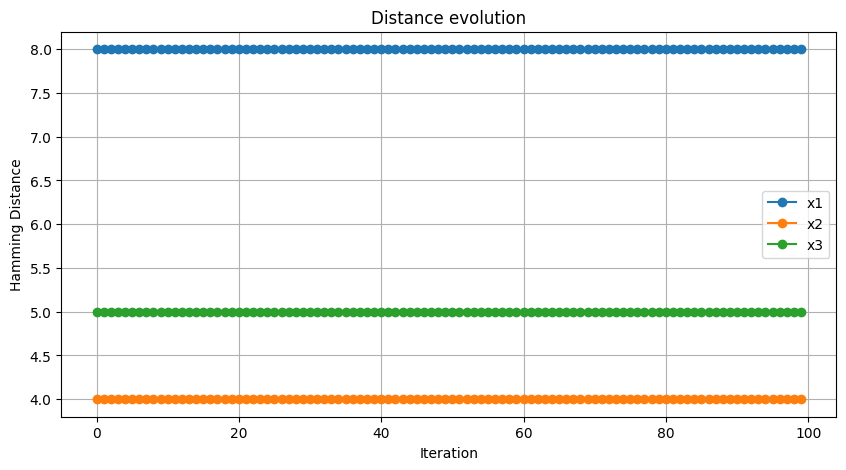

Spurious attractor (NOT stored)
[ 1  1  1  1  1 -1  1  1]
Nb of iterations:1


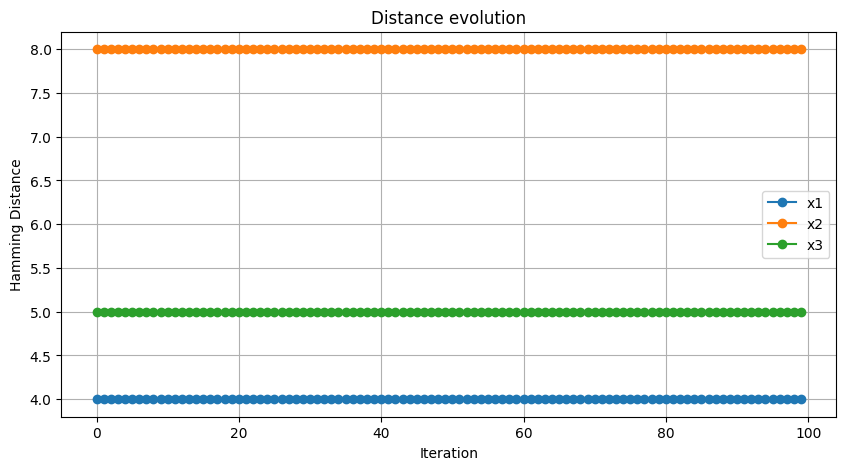

Spurious attractor (NOT stored)
[ 1 -1 -1  1  1 -1  1 -1]
Nb of iterations:1


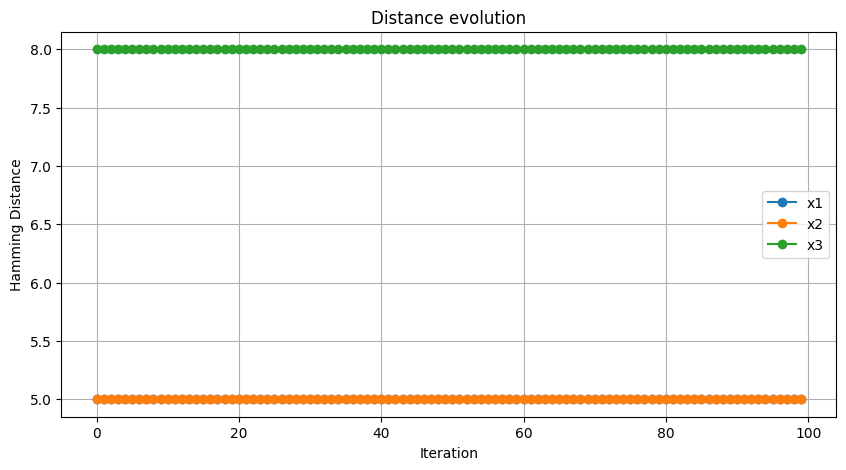

Spurious attractor (NOT stored)
[ 1 -1 -1  1  1 -1  1 -1]
Nb of iterations:3


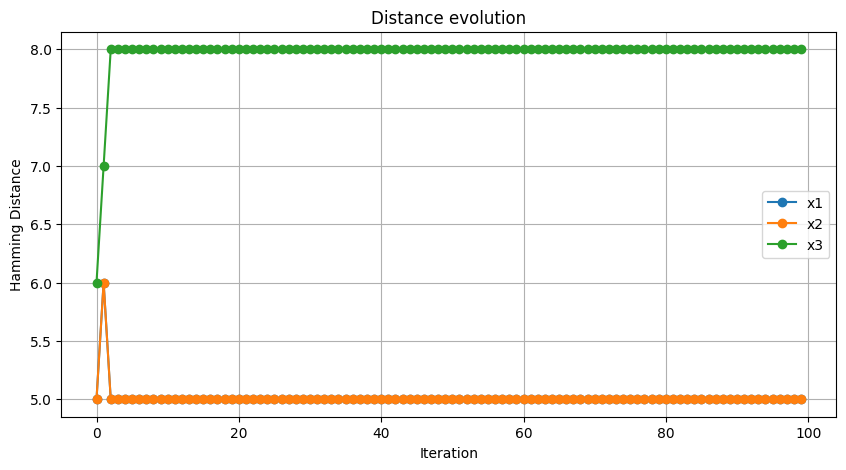

Spurious attractor (NOT stored)
[ 1  1 -1  1 -1  1  1 -1]
Nb of iterations:1


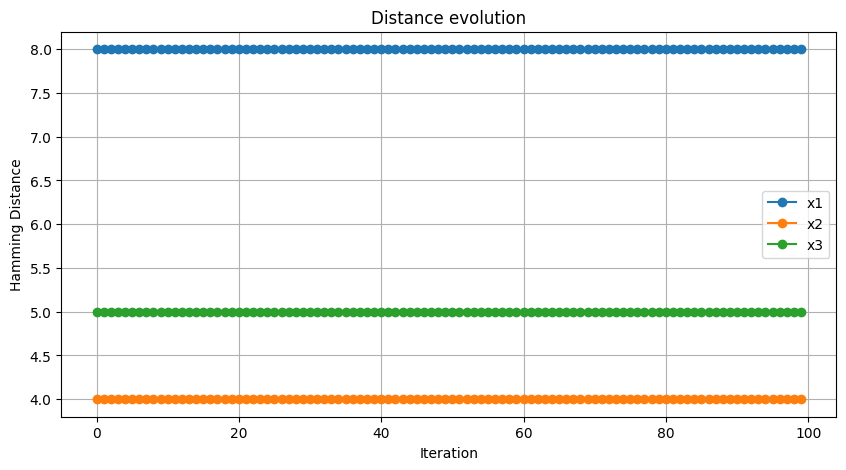

Spurious attractor (NOT stored)
[ 1  1  1  1  1 -1  1  1]
Nb of iterations:1


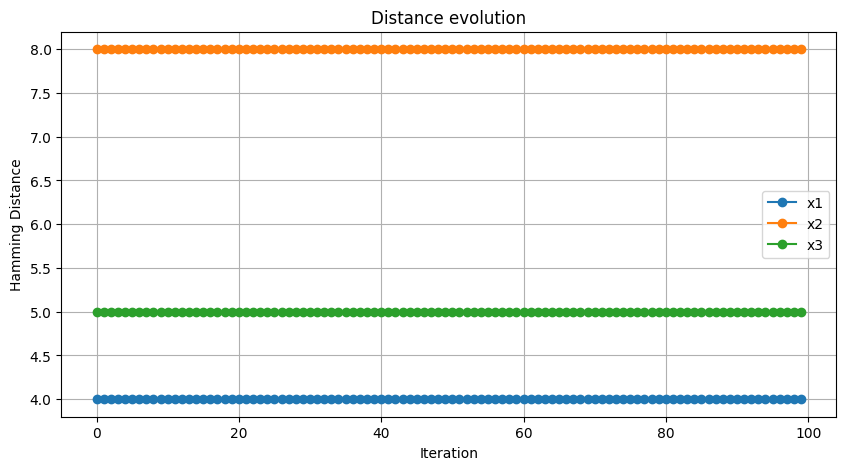

Spurious attractor (NOT stored)
[ 1 -1 -1  1  1 -1  1 -1]
Nb of iterations:1


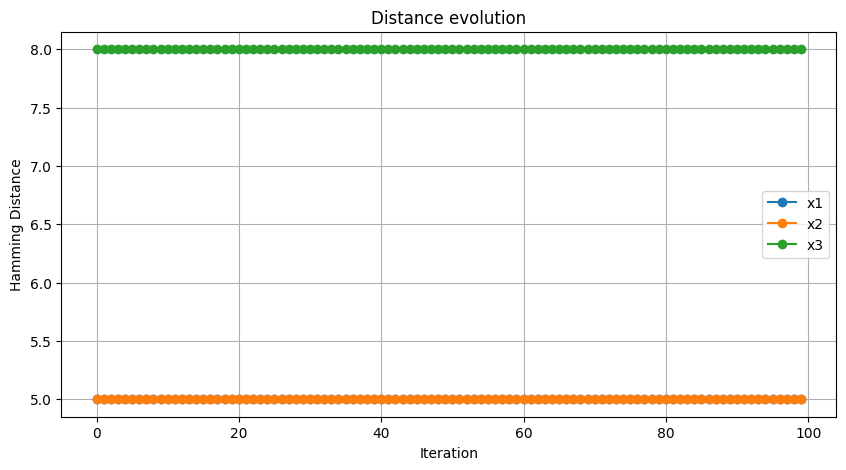

Spurious attractor (NOT stored)


In [71]:
# more dissimilar patterns

x1_very_dist = np.array([1, 1, -1, 1, -1, 1, 1, -1])
x2_very_dist = np.array([1, 1, 1, 1, 1, -1, 1, 1])
x3_very_dist = np.array([1, -1, -1, 1, 1, -1, 1, -1])
x_random = np.array([1, -1, 1, 1, -1, -1, 1, -1])
x1_inverse = -x1 
x2_inverse = -x2  
x3_inverse=-x3

X_very_dissimilar = [x1_very_dist, x2_very_dist, x3_very_dist, x_random, x1_inverse, x2_inverse, x3_inverse]

# results    
print("Converegence of very distorted patterns")

for x in X_very_dissimilar:
    new_x,iter=sync_hop(W,x,100)
    print(new_x)
    print(f"Nb of iterations:{iter}")
    plot_hamming(W, x,X, max_iter=100)

    if np.array_equal(new_x, x1):
        print("This is x1 (stored pattern)")
    elif np.array_equal(new_x, x2):
        print("This is x2 (stored pattern)")
    elif np.array_equal(new_x, x3):
        print("This is x3 (stored pattern) ")
    else:
        print("Spurious attractor (NOT stored)")



3.2 Sequential Update

In [72]:
import csv
# read pict.dat
with open("pict.dat", "r") as f:
    ligne=f.readline().strip()
    L=[int(x) for x in ligne.split(",")]

# create all patterns
Patterns={}
for i in range(11):
    Patterns[f"p{i+1}"]=(L[i*1024:(i+1)*1024])





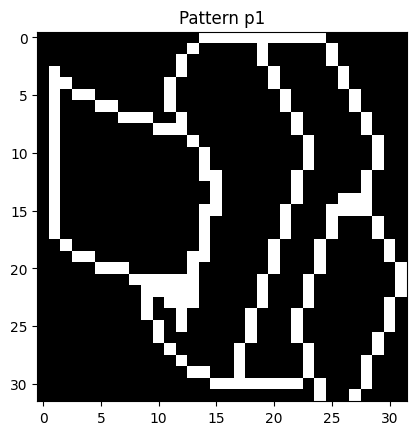

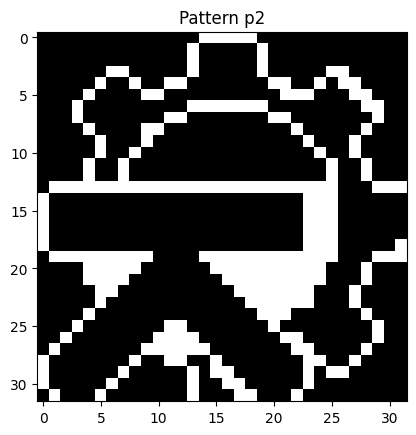

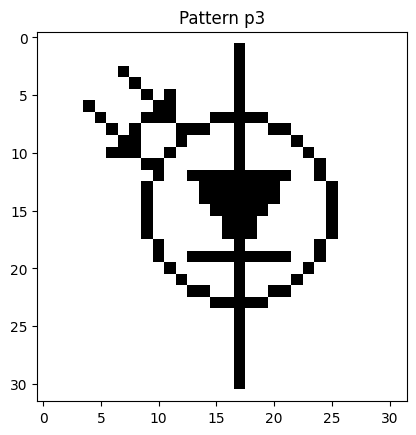

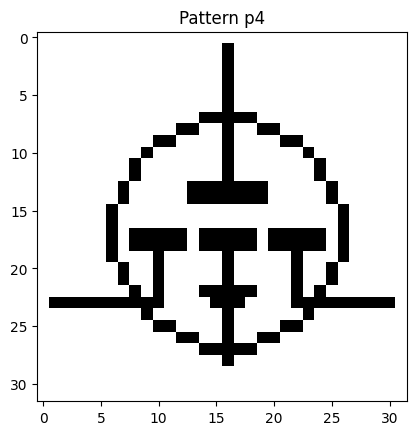

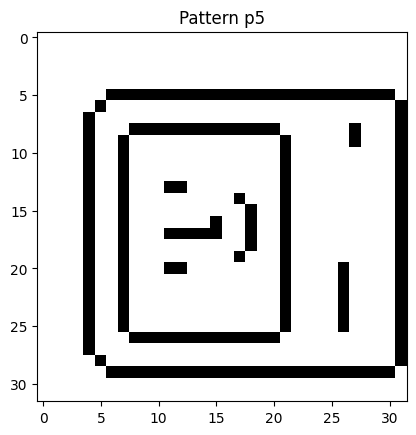

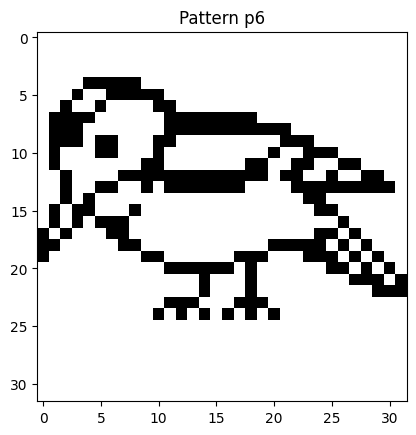

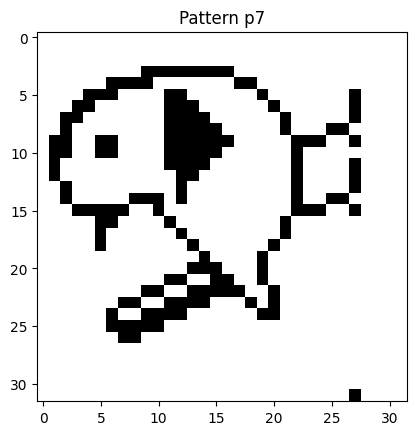

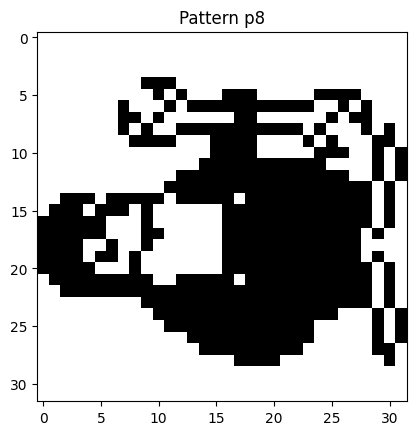

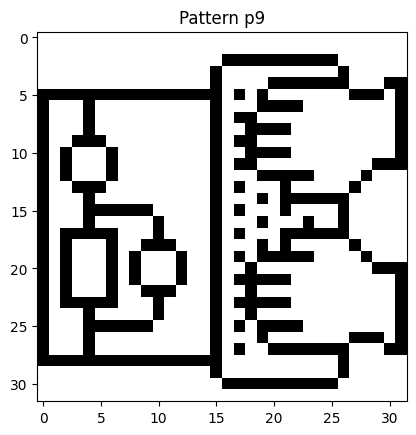

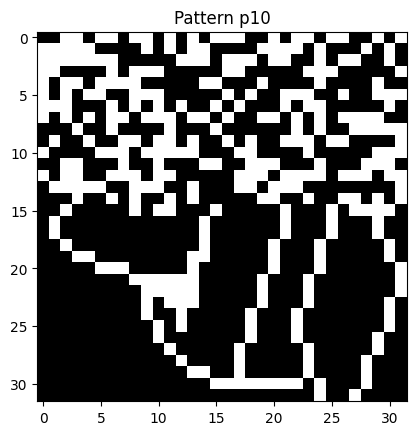

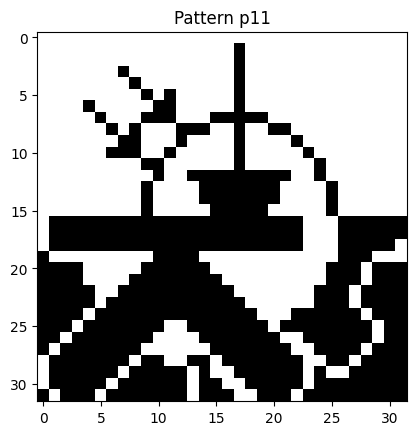

In [73]:
# create image viz

def img_show(k,v):
    img=np.array(v).reshape((32,32))
    plt.imshow(img,cmap='grey')
    plt.title(f"Pattern {k}" )
    plt.show()

for k,v in Patterns.items():
    img_show(k,v)

   


In [74]:
# learn p1,P2,p3
X_pict=[Patterns["p1"],Patterns["p2"],Patterns["p3"]]
W_pict=weight_hop(X_pict)

Check recall
-Check pattern 1
Nb iterations 1


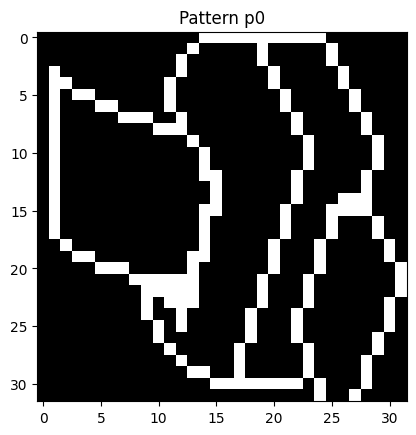

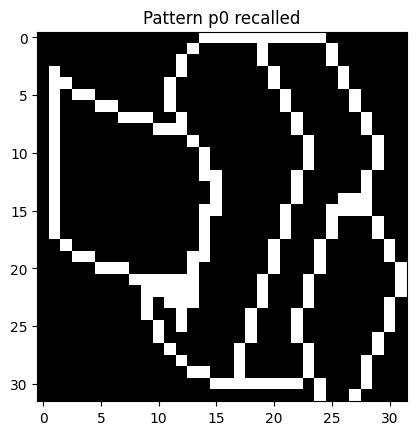

-Check pattern 2
Nb iterations 1


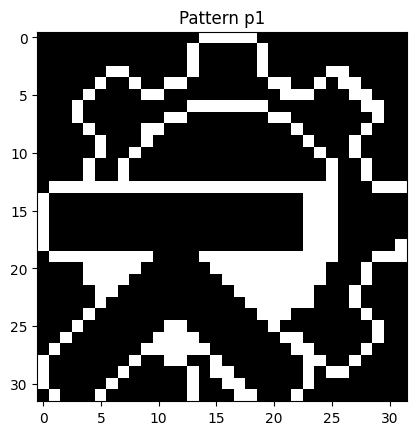

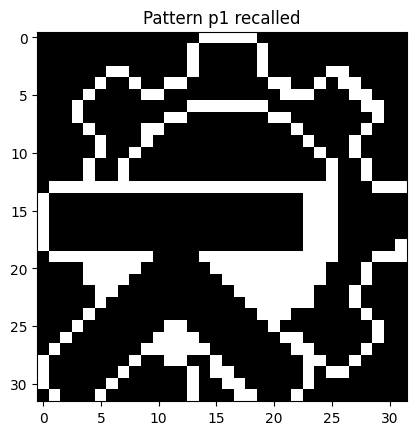

-Check pattern 3
Nb iterations 1


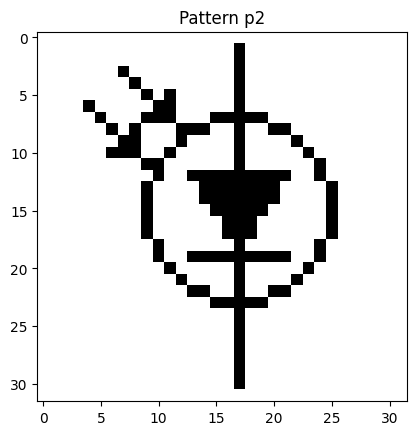

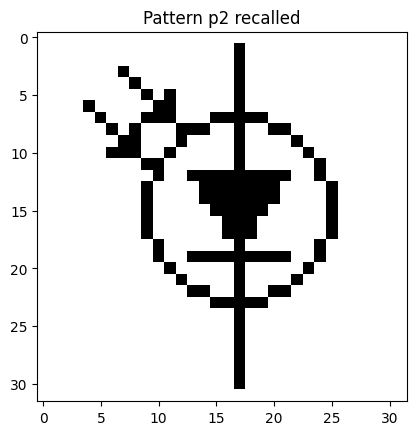

In [75]:
print("Check recall")
for i,x in enumerate(X_pict):
    print(f"-Check pattern {i+1}")
    new_x,iter=sync_hop(W_pict,x)
    print(f"Nb iterations {iter}")
    img_show(f"p{i}",x)
    img_show(f"p{i} recalled",new_x)

Nb of iterations:2


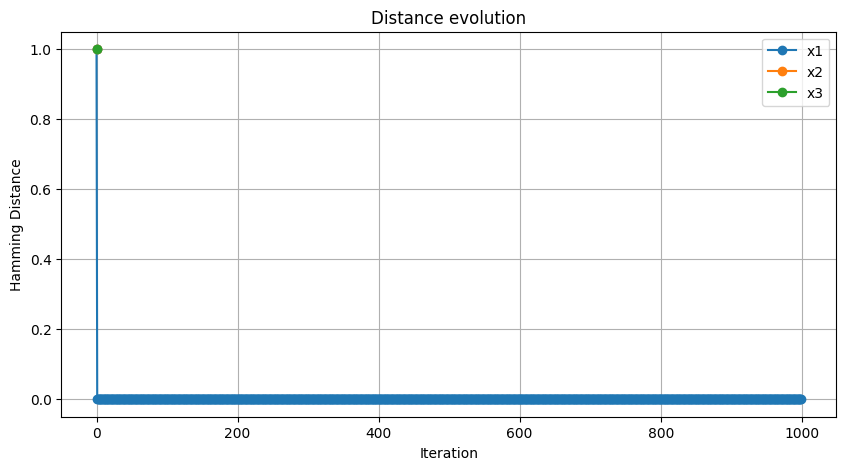

Nb of iterations:3


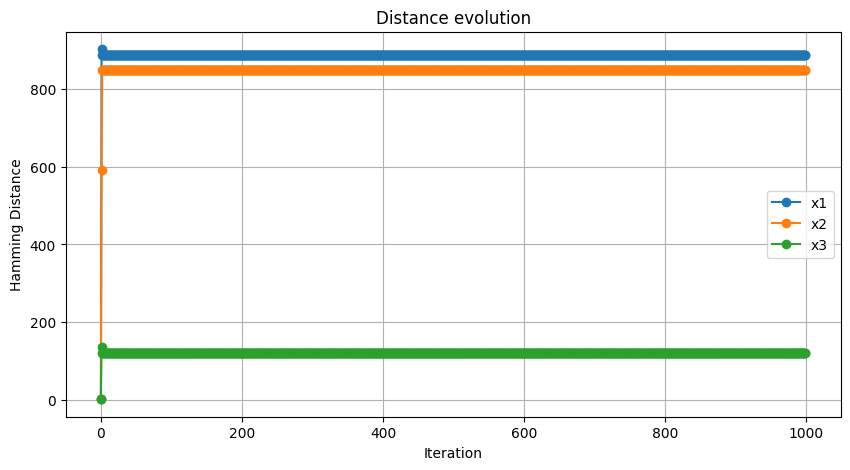

In [76]:
# test degraded patterns 10 and 11
new_x,iter=sync_hop(W_pict,Patterns["p10"],100)
print(f"Nb of iterations:{iter}")
plot_hamming(W_pict,Patterns["p10"] ,X_pict,1000)

new_x,iter=sync_hop(W_pict,Patterns["p11"],100)
print(f"Nb of iterations:{iter}")
plot_hamming(W_pict,Patterns["p11"] ,X_pict,1000)

### Asyncronous learning

In [77]:
def async_hop(x, W, target_patterns, max_iter=1000):
    
    x = x.copy()
    n = len(x)
    
    distances = {f'x{i+1}': [] for i in range(len(target_patterns))}

    for iter in range(max_iter):
        
        i = np.random.randint(n)
        
        x[i] = np.sign(np.dot(W[i], x))
      
        
        dist = [np.sum(x != t) for t in target_patterns]
        
        for j, d in enumerate(dist):
            distances[f'x{j+1}'].append(d)
        
        if iter % 100 == 0:
            min_dist = min(dist)
            img_show(f"Iter {iter} | Hamming closest = {min_dist}", x)
    
    # Plot
    plt.figure(figsize=(10,5))
    
    for name, dists in distances.items():
        plt.plot(dists, label=name)
    
    plt.xlabel('Iteration')
    plt.ylabel('Hamming Distance')
    plt.title('Distance evolution (asynchronous)')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    return x


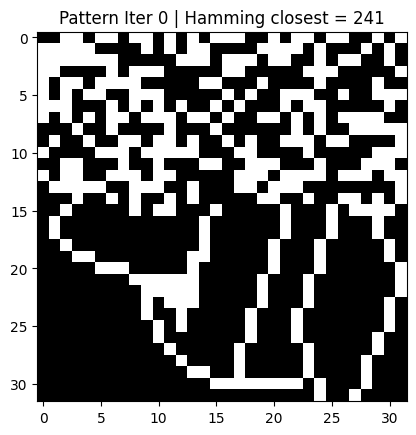

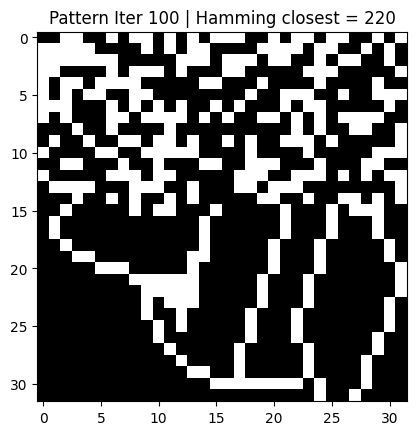

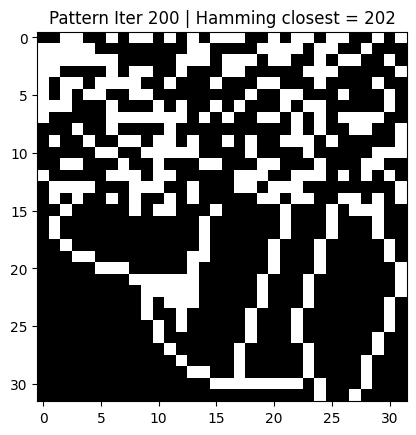

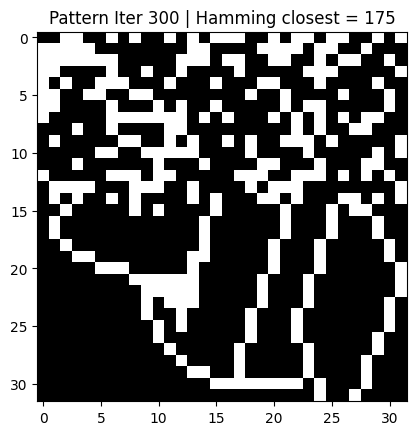

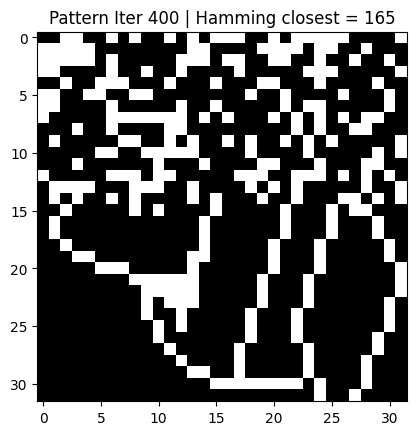

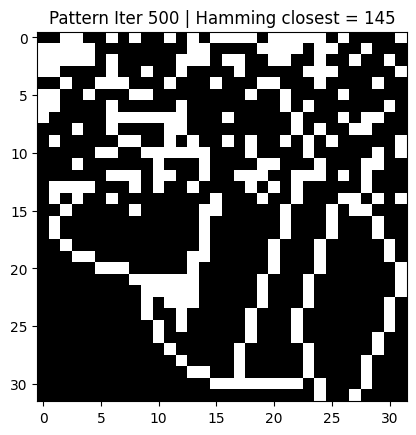

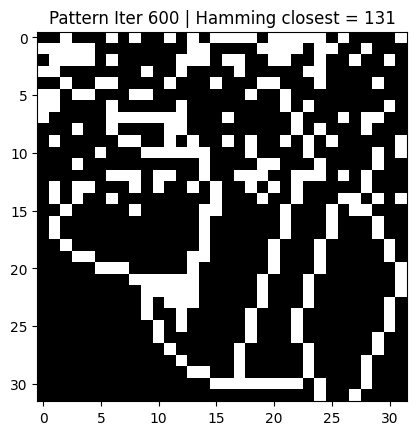

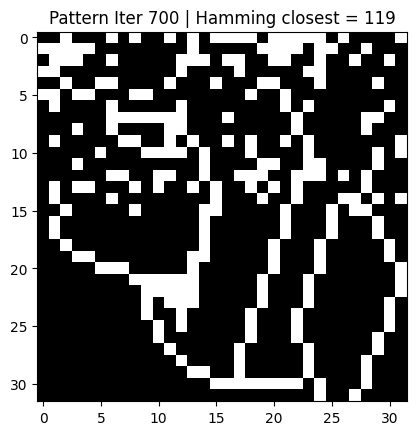

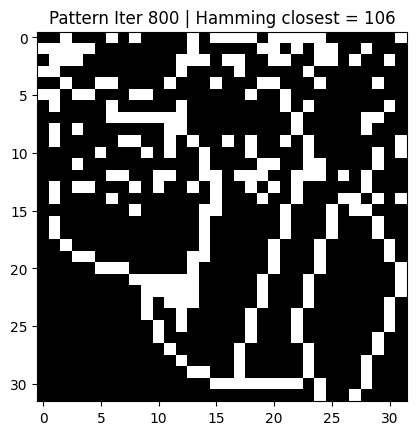

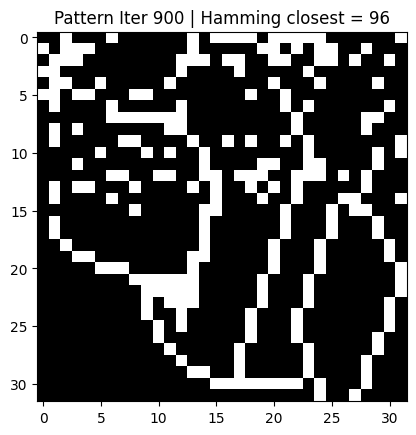

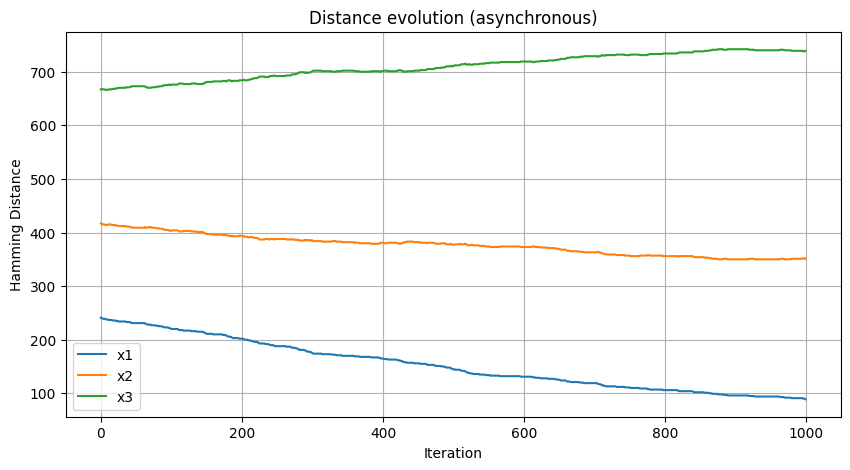

In [78]:
New_x_pict10=async_hop(np.array(Patterns["p10"]),W_pict,X_pict,1000)

### 3.3 Energy

In [81]:
def compute_energy(W,x):
    x=np.array(x)
    return -np.sum(x.T@W@x)

In [82]:
for i,x in enumerate(X_pict):
    e=compute_energy(W_pict,x)
    print(f"Energy for attractor {i+1}:{e}")


Energy for attractor 1:-490288.00000000006
Energy for attractor 2:-465114.66666666674
Energy for attractor 3:-498090.6666666668


In [83]:
# energy distorted patterns P10 and P11

e_10=compute_energy(W_pict,Patterns["p10"])
print(f"Energy for distorted patter p10:{e_10}")

e_11=compute_energy(W_pict,Patterns["p11"])
print(f"Energy for distorted patter p11:{e_11}")

Energy for distorted patter p10:-140964.0
Energy for distorted patter p11:-58197.3333333333


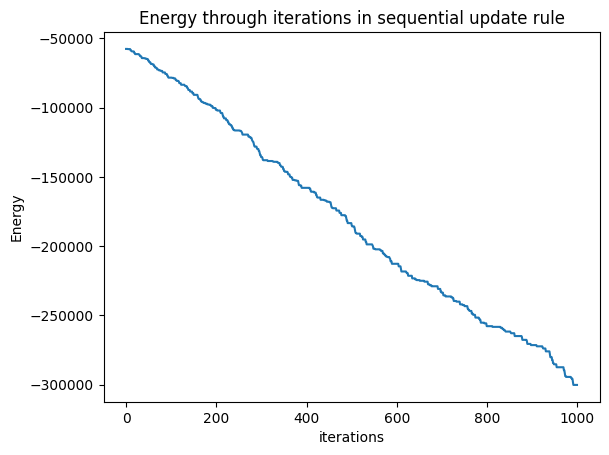

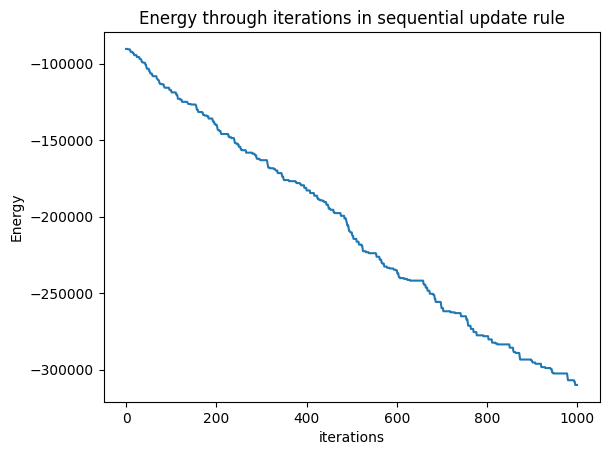

array([1, 1, 1, ..., 1, 1, 1])

In [95]:
# keep track on energy through iteration in sequential update rule 


def async_hop_energy(x, W, max_iter=1000):
    
    x = np.array(x.copy())
    n = len(x)
    E=[]

    for iter in range(max_iter):
        
        i = np.random.randint(n)
        
        x[i] = np.sign(np.dot(W[i,:],x))
      
        e=compute_energy(W,x)
        E.append(e)
    plt.plot(E)
    plt.title("Energy through iterations in sequential update rule")
    plt.xlabel("iterations")
    plt.ylabel("Energy")
    plt.show()
  
    return x

async_hop_energy(Patterns["p8"],W_pict)
async_hop_energy(Patterns["p9"],W_pict)

Random weights (normally distributed)

In [99]:
var=0.5
W_random = np.random.normal(0, var, (1024, 1024))


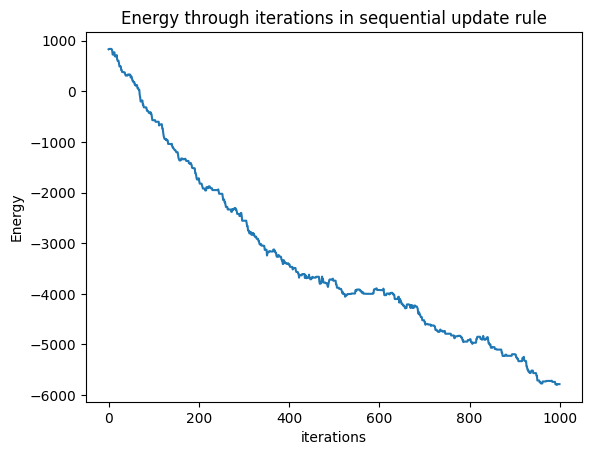

array([1, 1, 1, ..., 1, 1, 1])

In [104]:
async_hop_energy(Patterns["p8"],W_random)

Weight matrix symmetric

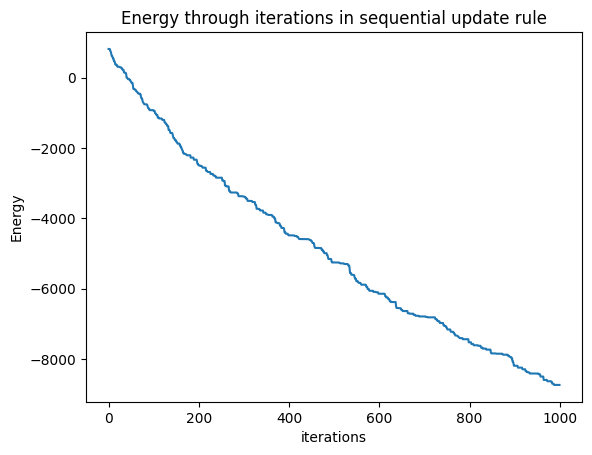

array([ 1, -1,  1, ..., -1,  1,  1])

In [106]:
W_sym=0.5*(W_random+W_random.T)
async_hop_energy(Patterns["p8"],W_sym)